In [1]:
%matplotlib inline

from math import ceil
from math import floor
from typing import Tuple
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
from einops import rearrange
from einops import repeat
from torch.nn import functional as F


FONTSIZE = 8
FPS = 30
DPI = 300  
COLORMAP = "turbo" 

DATA_DIR = '/home/bethge/bkr618/openretina_cache/euler_lab/hoefling_2024/stimuli/rgc_natstim_72x64_joint_normalized_2024-10-11.pkl'
H, W = 72, 64

In [2]:
def set_spine(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor("red")
        spine.set_linewidth(2)


def unfold_size(dim: int, patch_size: int, stride: int):
    return floor(((dim - patch_size) / stride) + 1)


def pad_size(dim: int, patch_size: int, stride: int):
    return (ceil(dim / stride) - 1) * stride + patch_size - dim


def zero_pad(frame: torch.Tensor, patch_size: int, stride: int):
    h_pad = pad_size(H, patch_size, stride)
    w_pad = pad_size(W, patch_size, stride)
    padding = (
        w_pad // 2,  # padding left
        w_pad - w_pad // 2,  # padding right
        h_pad // 2,  # padding top
        h_pad - h_pad // 2,  # padding bottom
    )
    print(f"pad: {padding}, frame shape: {frame.shape}")
    frame = rearrange(frame, "h w -> 1 h w")
    frame = F.pad(frame, pad=padding, mode="constant", value=0)
    # frame = F.pad(frame, pad=padding, mode="replicate")
    print(f"pad frame shape: {frame.shape}")
    frame = frame[0]
    return frame, padding


def unfold(frame: np.ndarray, patch_size: int, stride: int, pad: bool):
    frame = torch.from_numpy(frame)
    padding = None
    if pad:
        frame, padding = zero_pad(frame, patch_size, stride=stride)
    patches = frame.unfold(0, patch_size, stride).unfold(1, patch_size, stride)
    shape = patches.shape
    patches = rearrange(patches, "nh nw ph pw -> (nh nw) ph pw")
    patches = patches.numpy()
    return patches, shape, padding


def dropout(patches: np.ndarray, shape: Tuple[int, ...], p: float = 0.0):
    patches = torch.from_numpy(patches)
    patches = rearrange(patches, "n ph pw -> 1 n (ph pw)")
    patches = F.dropout(patches, p=p, training=True)
    patches = patches * (1 - p)  # dropout layer in PyTorch scale the output by 1/(1-p)
    patches = rearrange(patches, "1 n (ph pw) -> n ph pw", ph=shape[2], pw=shape[3])
    patches = patches.numpy()
    return patches


def dropout1d(patches: np.ndarray, shape: Tuple[int, ...], p: float = 0.0):
    patches = torch.from_numpy(patches)
    patches = rearrange(patches, "n ph pw -> 1 n (ph pw)")
    patches = F.dropout1d(patches, p=p, training=True)
    patches = patches * (1 - p)  # dropout layer in PyTorch scale the output by 1/(1-p)
    patches = rearrange(patches, "1 n (ph pw) -> n ph pw", ph=shape[2], pw=shape[3])
    patches = patches.numpy()
    return patches


def plot_patches(
    patches: np.ndarray,
    shape: tuple[int, int],
    title: str,
    cmap: str = "gray",
):
    nrows, ncols = shape[0], shape[1]
    figure, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(ncols * 0.1, nrows * 0.1),  # smaller scaling factor
        gridspec_kw={"wspace": 0.08, "hspace": 0.08},  # tight spacing
        facecolor="aquamarine",
        dpi=DPI,
    )
    axes = axes.ravel()
    for i in range(len(axes)):
        axes[i].imshow(patches[i], aspect="equal", cmap=cmap, vmin=0, vmax=1)
        axes[i].axis("off")
    top = axes[0].get_position()
    figure.text(
        x=0.5,
        y=top.y1 + 0.01,
        s=title,
        fontsize=FONTSIZE,
        ha="center",
    )
    plt.show()
    plt.close(figure)


def visualize_unfold(
    frame,
    patch_size: int = 7,
    stride: int = 2,
    p: float = 0.05,
):
    frame = frame / np.max(frame)

    figure, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 2), dpi=DPI)
    ax.imshow(frame, cmap="gray")
    ax.axis("off")
    plt.show()
    plt.close(figure)

    unfold_patches, shape, _ = unfold(
        frame, patch_size=patch_size, stride=stride, pad=False
    )
    plot_patches(unfold_patches, shape, title=f"unfold patches {shape} (no padding)")

    unfold_patches, shape, _ = unfold(
        frame, patch_size=patch_size, stride=stride, pad=True
    )
    plot_patches(unfold_patches, shape, title=f"unfold patches {shape} (with padding)")

    # dropout_patches = dropout(unfold_patches, shape, p=p)
    # plot_patches(dropout_patches, shape, title=f"dropout patches {shape} (p={p})")

    dropout1d_patches = dropout1d(unfold_patches, shape, p=p)
    plot_patches(dropout1d_patches, shape, title=f"dropout1d patches {shape} (p={p})")

In [3]:
from openretina.data_io.hoefling_2024.stimuli import movies_from_pickle
movies_path = '/home/bethge/bkr618/openretina_cache/euler_lab/hoefling_2024/stimuli/rgc_natstim_72x64_joint_normalized_2024-10-11.pkl'
movies_dict = movies_from_pickle(movies_path)

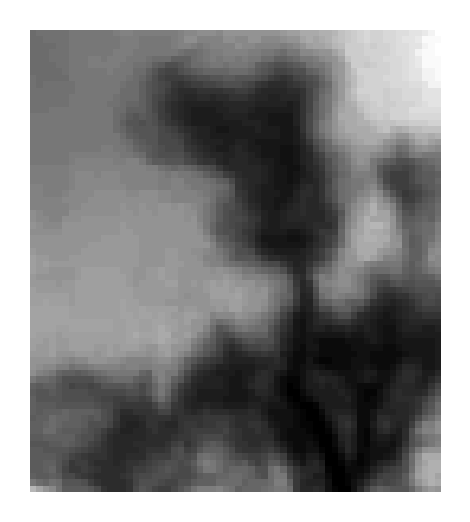

In [22]:
import random
movies = movies_dict.train
idx = random.randint(0,movies.shape[1])
example_frame = movies_dict.train[:,idx,:,:]
frame = example_frame[0] / np.max(example_frame[0])

figure, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 2), dpi=DPI)
ax.imshow(frame, cmap="gray")
ax.axis("off")
plt.show()
plt.close(figure)

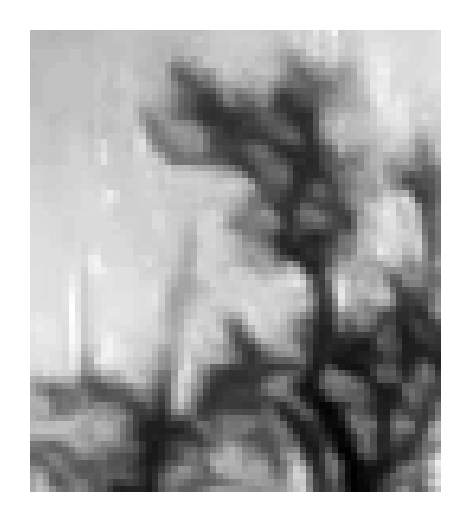

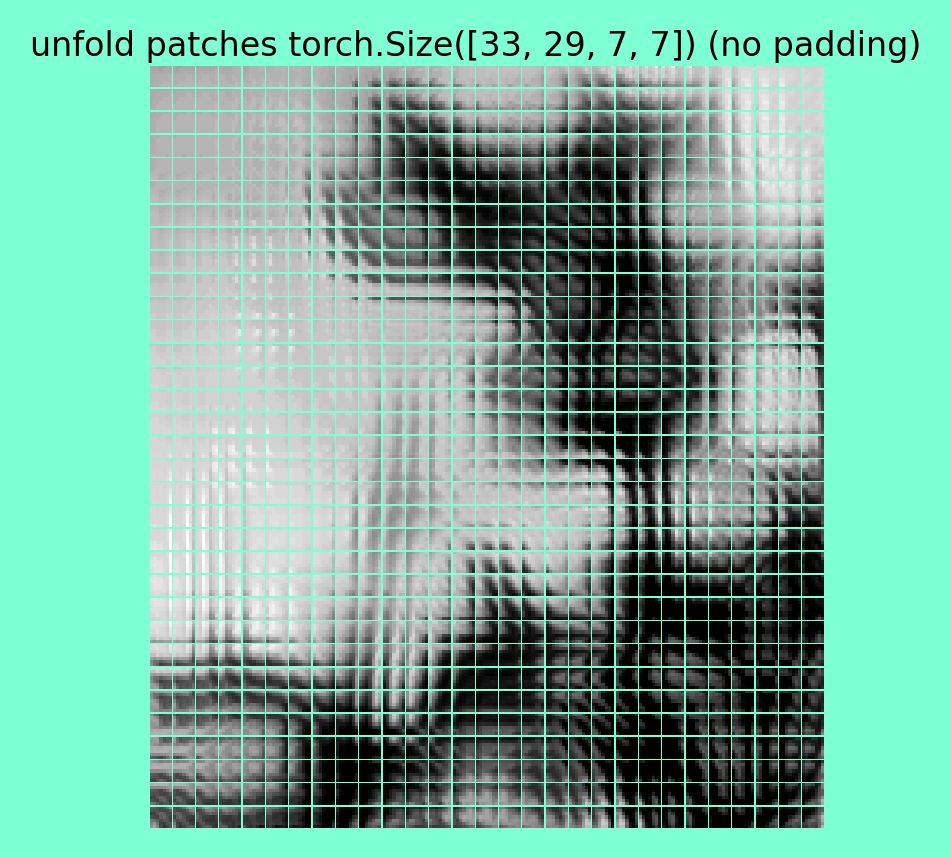

pad: (2, 3, 2, 3), frame shape: torch.Size([72, 64])
pad frame shape: torch.Size([1, 77, 69])


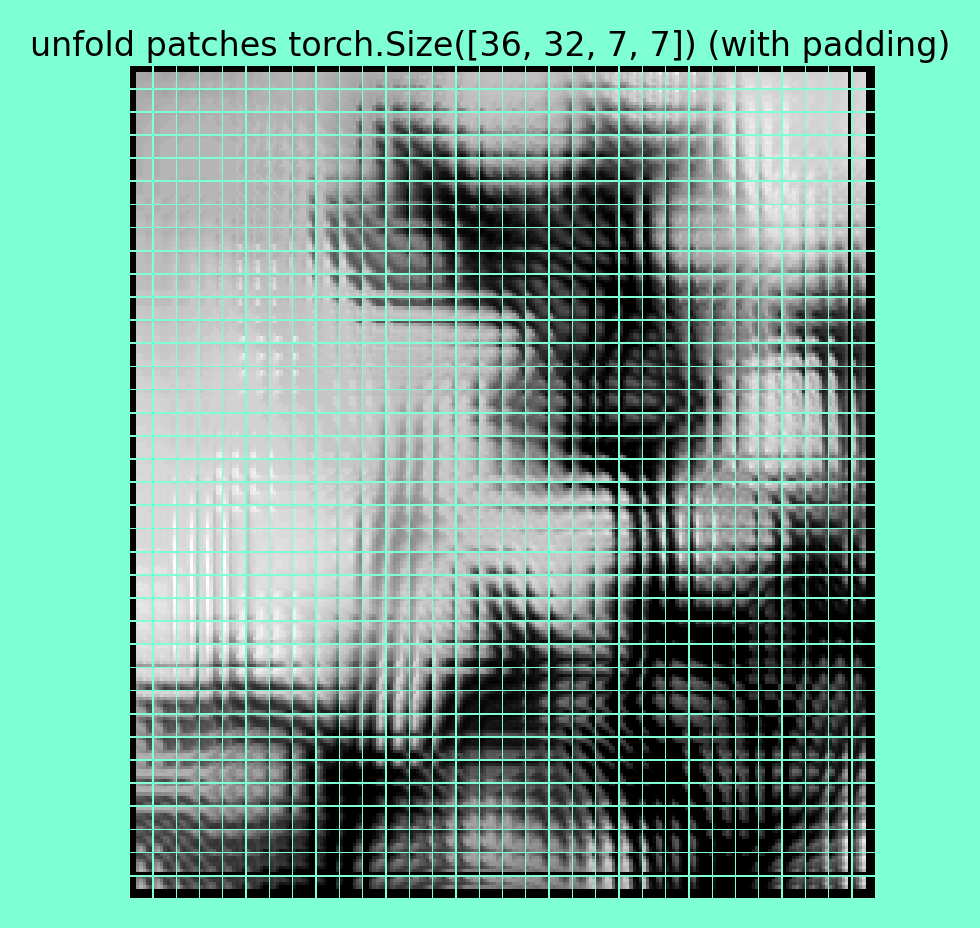

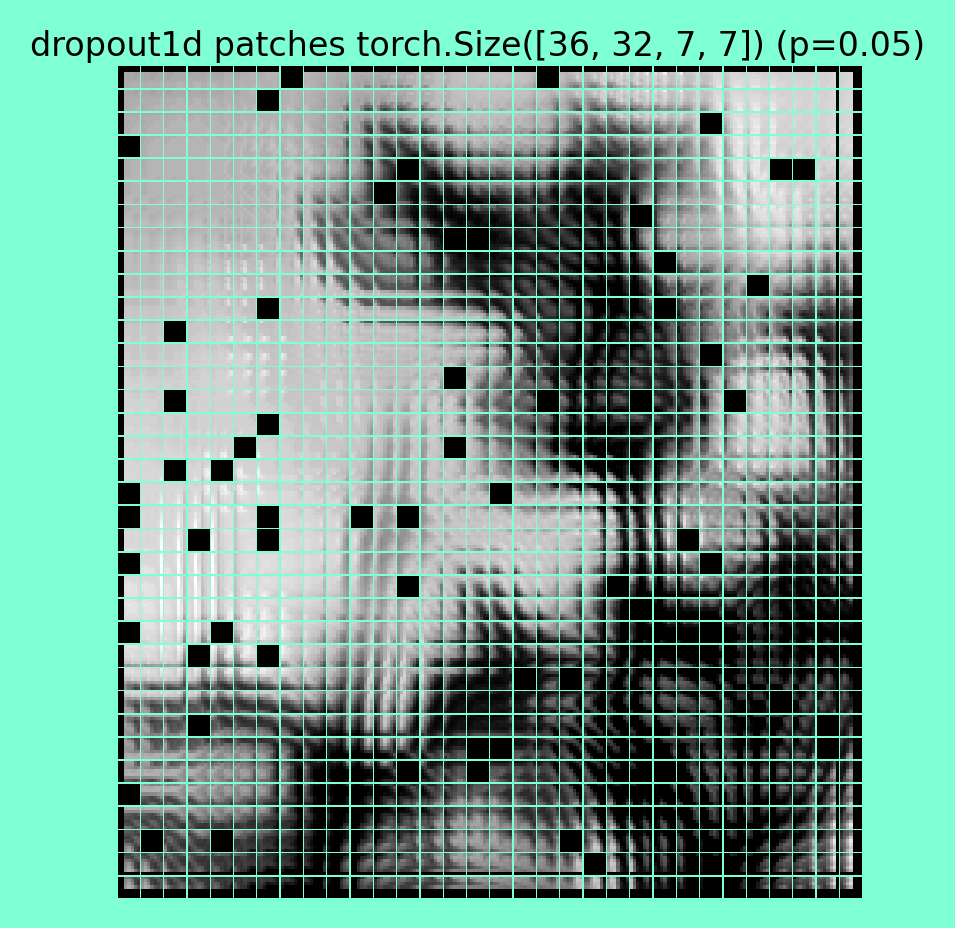

In [23]:
visualize_unfold(example_frame[1], patch_size=7, stride=2, p=0.05)